# Quick Ωm coverage diagnostic
Saved predictions and parameter labels only: **no images, inference, sampling, training, downloads or jobs**.
At each N, rank the 32 held-out cosmologies by nearest training-cosmology distance in six-dimensional parameter space using frozen training-only scales. Split into 16 nearer and 16 farther; ties use simulation ID. Membership changes with N. This is not TARP or a causal test. Actual results are pending execution on Great Lakes.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
PROJECT=Path("/home/jiamingp/diffusion_models_repo")
if not PROJECT.is_dir():
    PROJECT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"simdiff_eval").is_dir())
SWEEP="nf_conditional_bias_fresh_full_sweep_200k"
def path(s):
    p=Path(s)
    return p if p.is_absolute() else PROJECT/p
MANIFEST=PROJECT/"local"/SWEEP/"manifest.json"
PRED=PROJECT/"results"/SWEEP/"calibration_vgg/bias_probe_per_cosmology_points.csv"
CONTROL=PROJECT/"results/parameter_neighbor_control_v1/control_points.csv"
SCALES=PROJECT/"local/nf_conditional_bias_probe/heldout/param_norm_stats.json"
for f in [MANIFEST,PRED,SCALES]:
    if not f.is_file(): raise FileNotFoundError(f"Missing saved input: {f}; no inference fallback.")
rows=json.loads(MANIFEST.read_text())
scales=np.asarray(json.loads(SCALES.read_text())["std"],float)
assert scales.shape==(6,) and np.isfinite(scales).all() and (scales>0).all()
pred=pd.read_csv(PRED)
pred=pred[(pred.parameter=="Omega_m")&(pred.guidance_label=="noguidance")]
control=pd.read_csv(CONTROL) if CONTROL.is_file() else None
print("Sources:", MANIFEST, PRED, SCALES, sep="\n")
print("Real-control source:", CONTROL if control is not None else "MISSING; control comparison pending")
print("Verify real controls use the same frozen probe as the generated predictions.")


Sources:
/home/jiamingp/diffusion_models_repo/local/nf_conditional_bias_fresh_full_sweep_200k/manifest.json
/home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_fresh_full_sweep_200k/calibration_vgg/bias_probe_per_cosmology_points.csv
/home/jiamingp/diffusion_models_repo/local/nf_conditional_bias_probe/heldout/param_norm_stats.json
Real-control source: MISSING; control comparison pending
Verify real controls use the same frozen probe as the generated predictions.


In [2]:
def nearest_distance(train,sim,asked,heldout,scale):
    assert train.shape==(len(sim),6) and asked.shape==(32,6)
    assert np.isfinite(train).all() and np.isfinite(asked).all()
    assert len(np.unique(heldout))==32 and not np.intersect1d(sim,heldout).size
    unique,first=np.unique(sim,return_index=True)
    for s,i in zip(unique,first):
        assert np.allclose(train[sim==s],train[i],rtol=0,atol=1e-6)
    return np.linalg.norm((asked[:,None]-train[first][None])/scale,axis=2).min(axis=1)

parts=[]
assert len({r["dataset_size"] for r in rows})==len(rows)
for row in sorted(rows,key=lambda r:r["dataset_size"]):
    N=int(row["dataset_size"])
    p=pred[pred.run_name==row["run_name"]].copy()
    if p.empty:
        print("Missing predictions; skipping N =",N)
        continue
    assert len(p)==32 and not p.heldout_sim.duplicated().any()
    assert (p.dataset_size==N).all() and (p.n_samples==64).all()
    pairs=pd.read_csv(path(row["selected_pairs_path"]))
    train=np.load(path(row["train_raw_params_path"]),allow_pickle=False)
    heldout=np.atleast_1d(np.loadtxt(path(row["heldout_indices_path"]),dtype=int))
    asked=np.load(path(row["heldout_raw_params_path"]),allow_pickle=False)
    assert len(pairs)==N and len(train)==N
    assert np.array_equal(pairs.row,np.arange(N))
    assert not pairs.duplicated(["simulation_index","z_index"]).any()
    d=nearest_distance(train,pairs.simulation_index.to_numpy(),asked,heldout,scales)
    t=pd.DataFrame(dict(heldout_sim=heldout,requested=asked[:,0],distance=d))
    t=t.sort_values(["distance","heldout_sim"]).reset_index(drop=True)
    t["group"]=["Nearer 16"]*16+["Farther 16"]*16
    if np.isclose(t.distance.iloc[15],t.distance.iloc[16]):
        print("Boundary tie split by simulation ID at N =",N)
    t=t.merge(p[["heldout_sim","theta_in","theta_rec_median"]],on="heldout_sim",validate="one_to_one")
    assert len(t)==32 and np.allclose(t.requested,t.theta_in,atol=1e-6,rtol=0)
    t["generated_bias"]=t.theta_rec_median-t.requested
    t["real_bias"]=np.nan
    if control is not None:
        c=control[(control.run_name==row["run_name"])&(control.parameter=="Omega_m")&(control.kind=="heldout_real")]
        if len(c):
            assert len(c)==32 and not c.heldout_sim.duplicated().any()
            c=c.set_index("heldout_sim").reindex(t.heldout_sim)
            assert np.allclose(c.theta_in.to_numpy(),t.requested,rtol=0,atol=1e-6)
            t["real_bias"]=c.theta_rec_median.to_numpy()-t.requested.to_numpy()
    assert np.isfinite(t.generated_bias).all()
    t["N"]=N
    parts.append(t)
if not parts: raise RuntimeError("No matching saved predictions.")
data=pd.concat(parts,ignore_index=True)
assert all(set(t.heldout_sim)==set(parts[0].heldout_sim) for _,t in data.groupby("N"))
display(data.groupby(["N","group"]).agg(count=("heldout_sim","size"),
    median_distance=("distance","median"),median_requested_Omega_m=("requested","median"),
    real_controls=("real_bias","count")))


count  median_distance  median_requested_Omega_m  \
N     group                                                          
64    Farther 16     16         1.634523                    0.3020   
      Nearer 16      16         1.038367                    0.3054   
128   Farther 16     16         1.376235                    0.2804   
      Nearer 16      16         0.938803                    0.3336   
256   Farther 16     16         1.149507                    0.2804   
      Nearer 16      16         0.762307                    0.3294   
512   Farther 16     16         1.066028                    0.2804   
      Nearer 16      16         0.726738                    0.3660   
1024  Farther 16     16         0.961829                    0.2948   
      Nearer 16      16         0.721304                    0.3378   
2048  Farther 16     16         0.961829                    0.2948   
      Nearer 16      16         0.721304                    0.3378   
4096  Farther 16     16         0.961829                    0.2948   
      Nearer 16      16         0.721304                    0.3378   
8192  Farther 16     16         0.961829                    0.2948   
      Nearer 16      16         0.721304                    0.3378   
16384 Farther 16     16         0.961829                    0.2948   
      Nearer 16      16         0.721304                    0.3378   
32768 Farther 16     16         0.961829                    0.2948   
      Nearer 16      16         0.721304                    0.3378   

                  real_controls  
N     group                      
64    Farther 16              0  
      Nearer 16               0  
128   Farther 16              0  
      Nearer 16               0  
256   Farther 16              0  
      Nearer 16               0  
512   Farther 16              0  
      Nearer 16               0  
1024  Farther 16              0  
      Nearer 16               0  
2048  Farther 16              0  
      Nearer 16               0  
4096  Farther 16              0  
      Nearer 16               0  
8192  Farther 16              0  
      Nearer 16               0  
16384 Farther 16              0  
      Nearer 16               0  
32768 Farther 16              0  
      Nearer 16               0

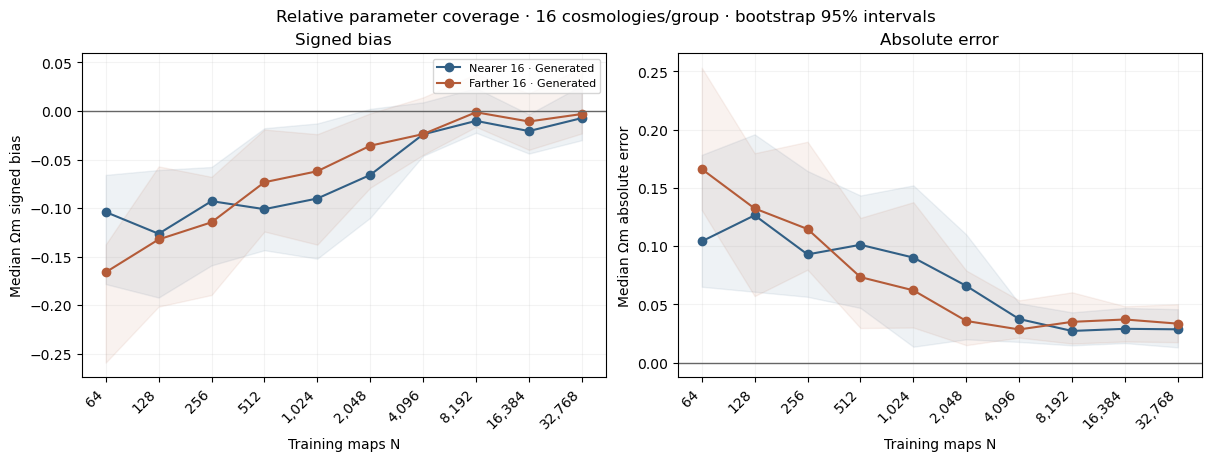

,N,group,source,metric,median,lo,hi
0,64,Farther 16,Generated,Signed bias,-0.1662,-0.2592,-0.1375
1,64,Farther 16,Generated,Absolute error,0.1662,0.1310,0.2531
2,64,Nearer 16,Generated,Signed bias,-0.1041,-0.1783,-0.0658
3,64,Nearer 16,Generated,Absolute error,0.1041,0.0651,0.1783
4,128,Farther 16,Generated,Signed bias,-0.1323,-0.2015,-0.0571
5,128,Farther 16,Generated,Absolute error,0.1323,0.0571,0.1797
6,128,Nearer 16,Generated,Signed bias,-0.1265,-0.1922,-0.0608
7,128,Nearer 16,Generated,Absolute error,0.1265,0.0608,0.1960
8,256,Farther 16,Generated,Signed bias,-0.1147,-0.1896,-0.0678
9,256,Farther 16,Generated,Absolute error,0.1147,0.0798,0.1896


In [3]:
rng=np.random.default_rng(123)
records=[]
for (N,group),part in data.groupby(["N","group"]):
    for source,col in [("Generated","generated_bias"),("Real control","real_bias")]:
        v=part[col].to_numpy(float)
        if not np.isfinite(v).all(): continue
        for metric in ["Signed bias","Absolute error"]:
            x=v if metric=="Signed bias" else np.abs(v)
            boot=np.median(x[rng.integers(0,len(x),size=(2000,len(x)))],axis=1)
            lo,hi=np.quantile(boot,[.025,.975])
            records.append(dict(N=N,group=group,source=source,metric=metric,
                                median=np.median(x),lo=lo,hi=hi))
summary=pd.DataFrame(records)
fig,axes=plt.subplots(1,2,figsize=(12,4.5),constrained_layout=True)
for ax,metric in zip(axes,["Signed bias","Absolute error"]):
    for group,color in [("Nearer 16","#315f85"),("Farther 16","#b45b38")]:
        for source,style,marker in [("Generated","-","o"),("Real control","--","s")]:
            s=summary[(summary.group==group)&(summary.source==source)&(summary.metric==metric)].sort_values("N")
            if s.empty: continue
            ax.plot(s.N,s["median"],color=color,ls=style,marker=marker,label=f"{group} · {source}")
            ax.fill_between(s.N.to_numpy(),s.lo.to_numpy(),s.hi.to_numpy(),color=color,alpha=.08)
    ax.axhline(0,color=".4",lw=1)
    ax.set_xscale("log",base=2)
    sizes=sorted(data.N.unique())
    ax.set_xticks(sizes)
    ax.set_xticklabels([f"{n:,}" for n in sizes],rotation=45,ha="right")
    ax.set(xlabel="Training maps N",ylabel=f"Median Ωm {metric.lower()}",title=metric)
    ax.grid(alpha=.15)
axes[0].legend(fontsize=8)
fig.suptitle("Relative parameter coverage · 16 cosmologies/group · bootstrap 95% intervals")
plt.show()
display(summary.round(4))


## Interpretation
Check whether farther cosmologies have larger **absolute** errors, and whether real controls show the same pattern. Signed biases can cancel. Requested Ωm differences can confound this comparison. Groups change at each N, so these are not fixed-cohort trajectories.

Bands use 2,000 within-group cosmology bootstrap resamples, not independent map resampling or training-seed variation. Missing controls are not treated as zero and never trigger inference. The notebook writes no result files; save an executed copy under a new name if desired. This quick diagnostic does not replace the proposed independent 100-cosmology posterior test.